In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

# Task 1

c:\NTHU\深度學習\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\NTHU\深度學習\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38917 (\N{CJK UNIFIED IDEOGRAPH-9805}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


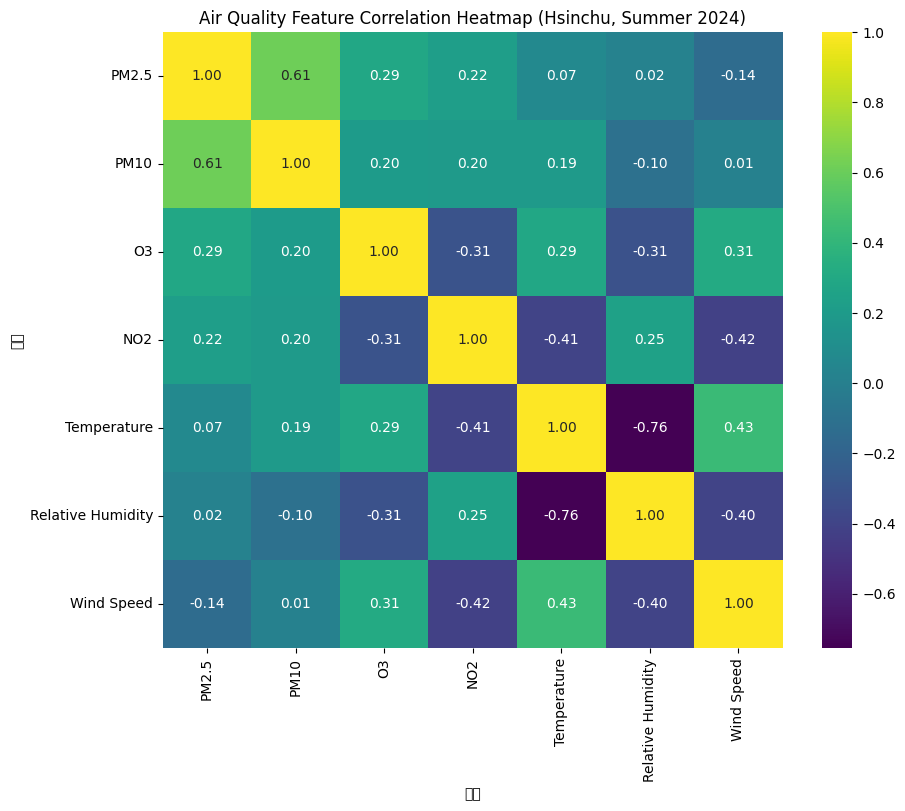

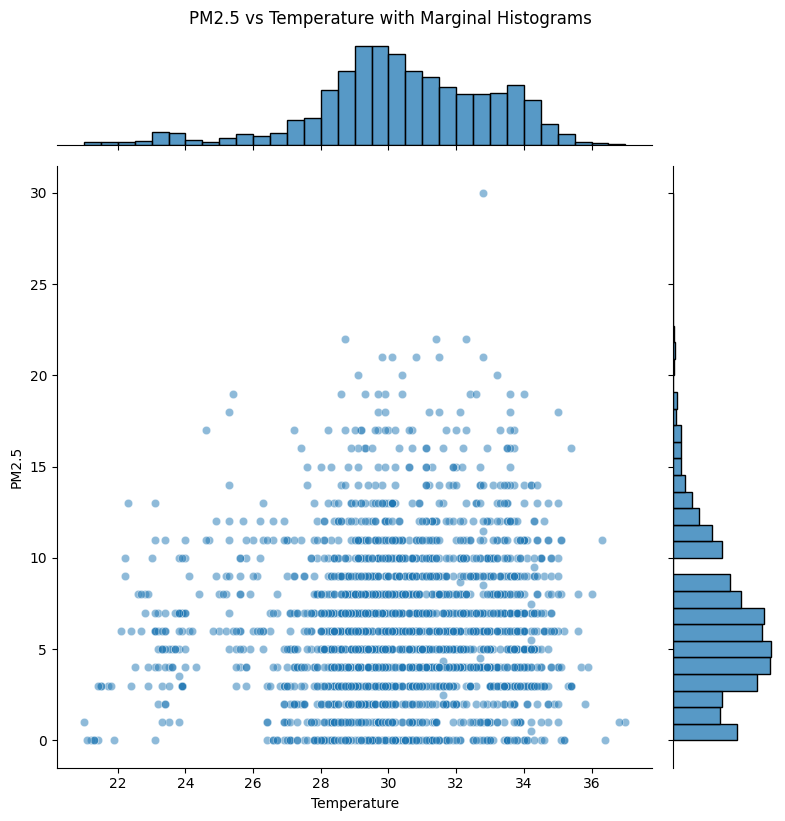

整理好的資料前 5 筆 (df_cleaned):
測項                   PM2.5  PM10    O3   NO2  Temperature  Relative Humidity  \
Timestamp                                                                      
2024-06-01 00:00:00    3.0   7.0  17.4   6.4         28.8               82.0   
2024-06-01 01:00:00    1.0   6.0  14.6   8.6         28.6               82.0   
2024-06-01 02:00:00    3.0   7.0   9.4   9.0         28.4               83.0   
2024-06-01 03:00:00    4.0  15.0   3.8  11.4         28.5               82.0   
2024-06-01 04:00:00    4.0   8.0   7.6   8.3         29.0               77.0   

測項                   Wind Speed  
Timestamp                        
2024-06-01 00:00:00         1.9  
2024-06-01 01:00:00         0.9  
2024-06-01 02:00:00         0.8  
2024-06-01 03:00:00         0.8  
2024-06-01 04:00:00         2.3  


In [ ]:
# 1. 讀取檔案
df = pd.read_csv('新竹_2024.csv')

# 2. 資料前處理 (Data Preprocessing)

# 定義 00~23 的小時欄位名稱
hour_columns = [f"{i:02d}" for i in range(24)]

# 轉換格式: 只 melt 我們確定是小時的那些欄位
df_melted = df.melt(id_vars=['測站', '日期', '測項'], value_vars=hour_columns, var_name='Hour', value_name='Value')

# 處理時間: 將 '日期' 和 'Hour' 合併成 datetime 格式
# 注意: 原始日期格式為 YYYY/MM/DD，我們先統一轉成 datetime object
df_melted['Date'] = pd.to_datetime(df_melted['日期']).dt.date
df_melted['Timestamp'] = pd.to_datetime(df_melted['Date'].astype(str) + ' ' + df_melted['Hour'] + ':00:00')

# 轉成數值: 將 'Value' 轉為數字，無法轉的變 NaN (例如 'NR')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

# 重塑資料 (Pivot): 讓每個測項變成一個欄位
df_pivot = df_melted.pivot(index='Timestamp', columns='測項', values='Value')

# 3. 篩選資料 (Filtering)
# 選取 2024 年夏季 (6月-8月)
df_summer = df_pivot.loc['2024-06-01':'2024-08-31'].copy()

# 選取需要的特徵並重新命名
target_features = {
    'PM2.5': 'PM2.5',
    'PM10': 'PM10',
    'O3': 'O3',
    'NO2': 'NO2',
    'AMB_TEMP': 'Temperature',
    'RH': 'Relative Humidity',
    'WIND_SPEED': 'Wind Speed'
}
df_cleaned = df_summer[list(target_features.keys())].rename(columns=target_features)

# 4. Missing Value Imputation
# 使用線性插值填補缺失值
df_cleaned = df_cleaned.interpolate(method='linear', limit_direction='both')

# 5. Visualization

# (1) Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_cleaned.corr()
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Air Quality Feature Correlation Heatmap (Hsinchu, Summer 2024)')
plt.show()

# (2) Scatter Plot with Marginal Histograms
# 繪製 PM2.5 vs Temperature
g = sns.jointplot(data=df_cleaned, x='Temperature', y='PM2.5', kind='scatter', alpha=0.5, height=8)
g.fig.suptitle('PM2.5 vs Temperature with Marginal Histograms', y=1.02)
plt.show()


# Task 2

正規化後的數據 (前 3 列):
[[0.1        0.17073171 0.24438202 0.16271186 0.4875     0.71428571
  0.25      ]
 [0.03333333 0.14634146 0.20505618 0.23728814 0.475      0.71428571
  0.09375   ]
 [0.1        0.17073171 0.13202247 0.25084746 0.4625     0.73469388
  0.078125  ]]

--- 資料集形狀檢查 ---
總共有幾筆樣本 (Samples): 2137
X (題目) 形狀: (2137, 48, 7) -> (筆數, 48小時, 7特徵)
y (答案) 形狀: (2137, 24) -> (筆數, 24小時)


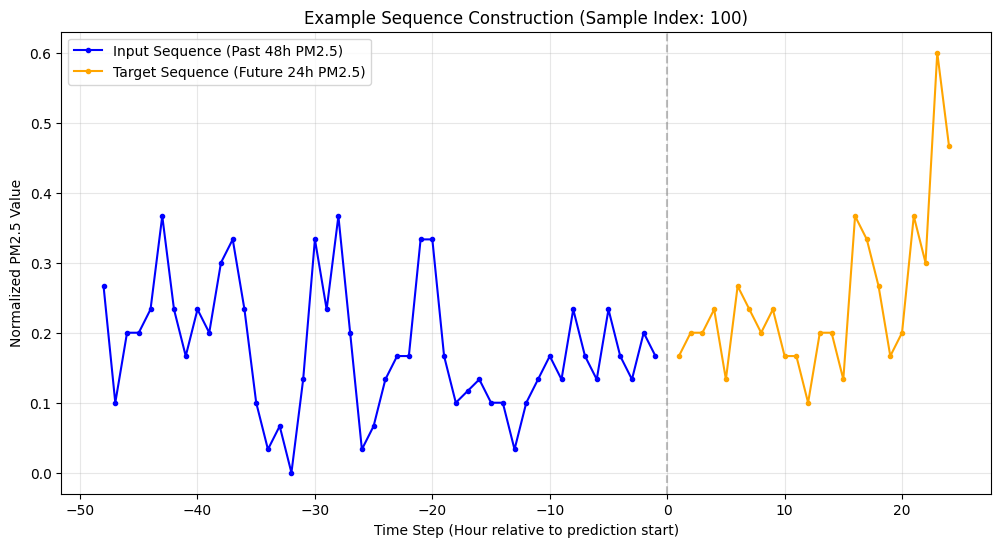

In [ ]:
# ==========================================
# 步驟 1: 數據正規化 (Normalization)
# ==========================================

scaler = MinMaxScaler()
# df_cleaned 是 Task 1 留下來的乾淨資料
# fit_transform 會先計算最大最小值，然後把資料轉成 0~1
data_scaled = scaler.fit_transform(df_cleaned)

print("正規化後的數據 (前 3 列):")
print(data_scaled[:3])

# ==========================================
# 步驟 2: 滑動視窗 (Sliding Window) 製作序列
# ==========================================
# 說明: 這就像是在錄影帶上移動一個視窗。
# 每移動一小時，我們就抓取一段「過去48小時」當題目，和「未來24小時」當答案。

def create_sequences(data, input_len=48, output_len=24):
    # data: 已經正規化過的所有資料
    # input_len: 輸入長度 (48小時)
    # output_len: 輸出長度 (24小時)
    
    X = [] # 用來存題目
    y = [] # 用來存答案
    
    # 找出 PM2.5 在第幾個欄位 (因為答案只要預測 PM2.5)
    # 我們在 Task 1 設定 target_features 時，PM2.5 是第一個 (key 0)
    # 為了保險，我們印出來確認一下
    # df_cleaned.columns 的順序就是 data_scaled 的欄位順序
    pm25_index = df_cleaned.columns.get_loc('PM2.5')
    
    total_len = len(data)
    
    # 開始滑動視窗
    # 迴圈範圍：從 0 開始，直到剩下的資料不夠湊成一組 (input + output) 為止
    for i in range(total_len - input_len - output_len + 1):
        # 題目: 從 i 開始，抓 input_len (48) 小時，抓取所有特徵
        input_seq = data[i : i + input_len]
        
        # 答案: 接在題目後面，抓 output_len (24) 小時
        # 注意: 我們只需要預測 PM2.5，所以只抓 pm25_index 這一欄
        output_seq = data[i + input_len : i + input_len + output_len, pm25_index]
        
        X.append(input_seq)
        y.append(output_seq)
        
    return np.array(X), np.array(y)

# 設定長度參數
INPUT_LEN = 48
OUTPUT_LEN = 24

# 執行函式
X, y = create_sequences(data_scaled, INPUT_LEN, OUTPUT_LEN)

# ==========================================
# 步驟 3: 顯示形狀與視覺化範例 
# ==========================================

print("\n--- 資料集形狀檢查 ---")
print(f"總共有幾筆樣本 (Samples): {X.shape[0]}")
print(f"X (題目) 形狀: {X.shape} -> (筆數, 48小時, 7特徵)")
print(f"y (答案) 形狀: {y.shape} -> (筆數, 24小時)")

# 畫出一個範例來檢查
# 我們隨便選第 100 筆資料
sample_idx = 100

plt.figure(figsize=(12, 6))

# 畫出「過去 48 小時」的 PM2.5 (題目)
# X[sample_idx, :, 0] 意思是：第100筆, 所有時間點, 第0個特徵(PM2.5)
# 為了讓圖好看，我們設 X 軸為 -48 到 0
time_x = np.arange(-INPUT_LEN, 0)
plt.plot(time_x, X[sample_idx, :, 0], label='Input Sequence (Past 48h PM2.5)', marker='.', color='blue')

# 畫出「未來 24 小時」的 PM2.5 (真實答案)
# y[sample_idx] 就是那 24 個 PM2.5 數值
time_y = np.arange(1, OUTPUT_LEN + 1)
plt.plot(time_y, y[sample_idx], label='Target Sequence (Future 24h PM2.5)', marker='.', color='orange')

plt.title(f'Example Sequence Construction (Sample Index: {sample_idx})')
plt.xlabel('Time Step (Hour relative to prediction start)')
plt.ylabel('Normalized PM2.5 Value')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5) # 畫一條虛線分隔過去和未來
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 提醒: 
# 我們現在手上有 X 和 y 變數，接下來 Task 3 會把它們拆成 
# 訓練集 (Training)、驗證集 (Validation)、測試集 (Test)。

In [9]:
# ==========================================
# Task 3: LSTM 模型訓練 (LSTM Training)
# ==========================================
print("--- Task 3: LSTM Forecasting ---")

# 1. 資料切分 (70% / 15% / 15%)
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = torch.FloatTensor(X[:train_size]).to(device)
y_train = torch.FloatTensor(y[:train_size]).to(device)
X_val = torch.FloatTensor(X[train_size:train_size+val_size]).to(device)
y_val = torch.FloatTensor(y[train_size:train_size+val_size]).to(device)
X_test = torch.FloatTensor(X[train_size+val_size:]).to(device)
y_test = torch.FloatTensor(y[train_size+val_size:]).to(device)

# 2. 手刻 LSTM (Manually Implemented LSTM)
class ManualLSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz, out_sz):
        super().__init__()
        self.hidden_sz = hidden_sz
        
        # 定義權重 (Weights)
        self.W_x = nn.Linear(input_sz, hidden_sz * 4) 
        self.W_h = nn.Linear(hidden_sz, hidden_sz * 4)
        self.fc = nn.Linear(hidden_sz, out_sz)
        
    def forward(self, x):
        bs, seq, _ = x.shape
        # 初始化 Hidden state 和 Cell state
        h = torch.zeros(bs, self.hidden_sz).to(x.device)
        c = torch.zeros(bs, self.hidden_sz).to(x.device)
        
        for t in range(seq):
            gates = self.W_x(x[:, t, :]) + self.W_h(h)
            i_gate, f_gate, g_gate, o_gate = gates.chunk(4, 1)
            
            i = torch.sigmoid(i_gate)
            f = torch.sigmoid(f_gate)
            g = torch.tanh(g_gate)
            o = torch.sigmoid(o_gate)
            
            c = f * c + i * g
            h = o * torch.tanh(c)
            
        return self.fc(h)

# 參數設定
hidden_size = 64
model = ManualLSTM(input_sz=7, hidden_sz=hidden_size, out_sz=24).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 3. 訓練迴圈
epochs = 50
batch_size = 32
train_losses, val_losses = [], []

print("Training started...")
for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size()[0])
    epoch_loss = 0
    
    for i in range(0, X_train.size()[0], batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[idx], y_train[idx]
        
        optimizer.zero_grad()
        out = model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_train = epoch_loss / (len(X_train)/batch_size)
    train_losses.append(avg_train)
    
    model.eval()
    with torch.no_grad():
        val_out = model(X_val)
        val_loss = criterion(val_out, y_val).item()
        val_losses.append(val_loss)
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train:.5f}, Val Loss: {val_loss:.5f}")

# [圖3] Loss 曲線
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# ==========================================
# Task 3 (Cont.): 預測與評估 (Evaluation)
# ==========================================

# 1. 執行預測
model.eval()
with torch.no_grad():
    preds = model(X_test).cpu().numpy()
    y_true = y_test.cpu().numpy()
    X_test_cpu = X_test.cpu().numpy()

# 2. 反正規化 (Inverse Transform)
# 只需要 PM2.5 的參數來還原
pm25_min = scaler.min_[0]
pm25_scale = scaler.scale_[0]

def inverse_pm25(scaled_val):
    return (scaled_val - pm25_min) / pm25_scale

preds_real = inverse_pm25(preds)
y_true_real = inverse_pm25(y_true)
# Input 也需要還原 PM2.5 那一欄 (index 0) 才能畫圖
input_real = inverse_pm25(X_test_cpu[:, :, 0]) 

# 3. 計算指標 (Metrics)
mae = np.mean(np.abs(y_true_real - preds_real))
rmse = np.sqrt(np.mean((y_true_real - preds_real)**2))
# 為了避免除以 0，加一個微小值
mape = np.mean(np.abs((y_true_real - preds_real) / (y_true_real + 1e-5))) * 100

print("\n--- Quantitative Metrics ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

# [圖4] 5 組預測結果視覺化
# 挑選 5 個不同時間點的樣本
sample_indices = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(5, 1, figsize=(10, 18))
plt.subplots_adjust(hspace=0.4)

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    
    # 準備 X 軸時間 (小時)
    t_in = np.arange(-48, 0)
    t_out = np.arange(1, 25)
    
    # 畫圖
    ax.plot(t_in, input_real[idx], label='Input (Past 48h)', color='blue', marker='.')
    ax.plot(t_out, y_true_real[idx], label='Ground Truth (Future 24h)', color='green', marker='o')
    ax.plot(t_out, preds_real[idx], label='Prediction (Future 24h)', color='red', linestyle='--', marker='x')
    
    ax.set_title(f'Test Sample Index: {idx}')
    ax.set_ylabel('PM2.5')
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    if i == 0:
        ax.legend(loc='upper left')

plt.xlabel('Time (Hours)')
plt.show()

--- Task 3: LSTM Forecasting ---


NameError: name 'device' is not defined